In [1]:
import pandas as pd
from sktime.datasets import load_gunpoint
from sktime.clustering.k_means import TimeSeriesKMeans
import seaborn as sns
from sktime.utils.plotting import plot_series
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Clustering

In [2]:
X_train, y_train = load_gunpoint(split="TRAIN", return_type="numpy3D")
X_train.shape, y_train.shape

((50, 1, 150), (50,))

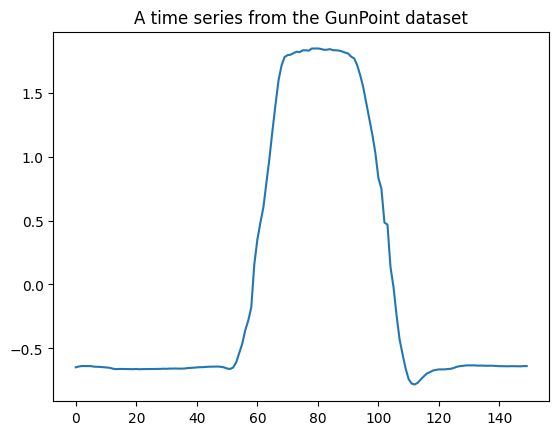

In [3]:
plt.title("A time series from the GunPoint dataset")
plt.plot(X_train[0].T)

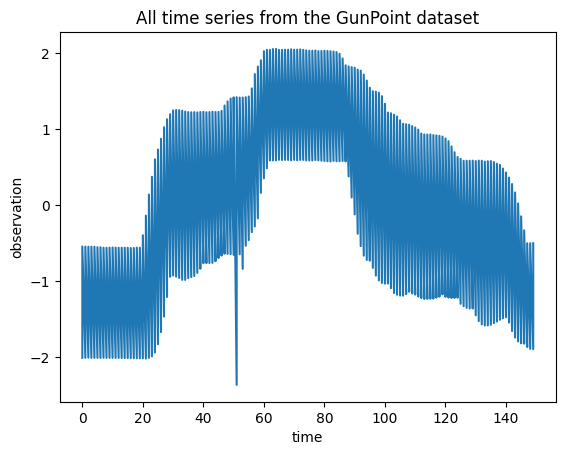

In [4]:
df = pd.DataFrame(np.squeeze(X_train))
df_melt = df.melt(value_name="observation", var_name="time")
sns.lineplot(df_melt, x="time", y="observation", estimator=None)
plt.title("All time series from the GunPoint dataset")
plt.show()

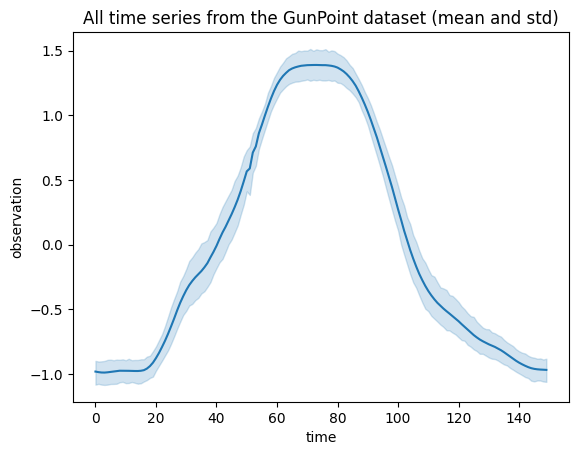

In [5]:
sns.lineplot(df_melt, x="time", y="observation", estimator="mean")
plt.title("All time series from the GunPoint dataset (mean and std)")
plt.show()

## Distance-based Clustering

### Euclidean

In [6]:
clusterer = TimeSeriesKMeans(n_clusters=2, metric="euclidean")

In [7]:
%%time
clusterer.fit(X_train)

CPU times: user 220 ms, sys: 7.72 ms, total: 228 ms
Wall time: 90.1 ms


TimeSeriesKMeans(metric='euclidean', n_clusters=2)

In [8]:
df["cluster"] = clusterer.labels_
df.head()

,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,cluster
0,-0.647885,-0.641992,-0.638186,-0.638259,-0.638345,-0.638697,-0.643049,-0.643768,-0.645050,-0.647118,...,-0.639716,-0.639735,-0.640184,-0.639235,-0.639395,-0.640231,-0.640429,-0.638666,-0.638657,1
1,-0.644427,-0.645401,-0.647055,-0.647492,-0.646910,-0.643884,-0.639731,-0.638094,-0.635297,-0.635384,...,-0.641426,-0.639267,-0.637797,-0.637680,-0.635260,-0.635490,-0.634934,-0.634497,-0.631596,1
2,-0.778353,-0.778279,-0.777151,-0.777684,-0.775900,-0.772421,-0.765464,-0.762275,-0.763752,-0.765356,...,-0.718712,-0.713534,-0.710021,-0.704126,-0.703263,-0.703393,-0.704196,-0.707605,-0.707120,1
3,-0.750060,-0.748103,-0.746164,-0.745926,-0.743767,-0.743805,-0.745213,-0.745082,-0.745727,-0.745815,...,-0.724661,-0.729229,-0.728940,-0.727834,-0.728244,-0.726453,-0.725517,-0.725191,-0.724679,1
4,-0.599539,-0.597422,-0.599269,-0.598259,-0.597582,-0.591303,-0.589020,-0.587533,-0.585462,-0.583847,...,-0.643885,-0.645742,-0.646458,-0.646464,-0.645585,-0.642412,-0.643337,-0.636803,-0.631716,1


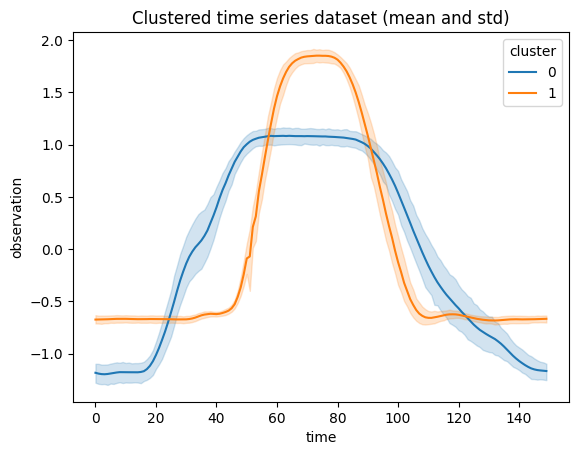

In [9]:
df_melt = df.melt(value_name="observation", var_name="time", id_vars="cluster")
sns.lineplot(df_melt, x="time", y="observation", hue="cluster")
plt.title("Clustered time series dataset (mean and std)")
plt.show()

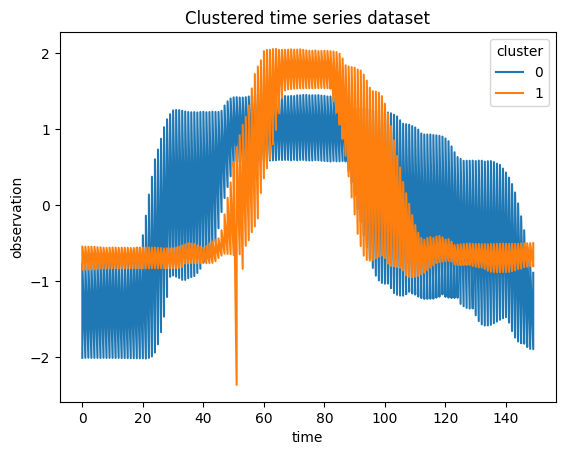

In [10]:
sns.lineplot(df_melt, x="time", y="observation", hue="cluster", estimator=None)
plt.title("Clustered time series dataset")
plt.show()

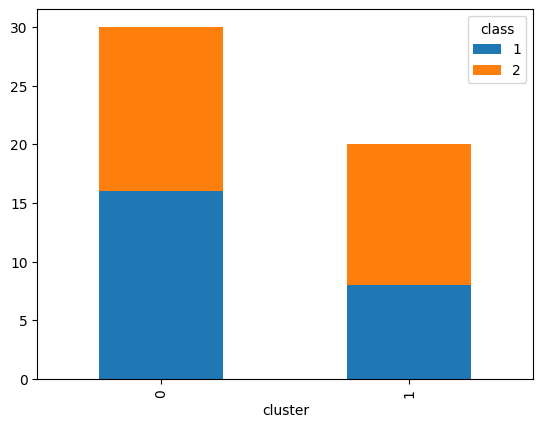

In [11]:
pd.crosstab(df["cluster"], y_train).plot(kind="bar", stacked=True)
plt.legend(title="class")

### DTW

In [12]:
clusterer = TimeSeriesKMeans(n_clusters=2, metric="dtw", 
                             distance_params={'itakura_max_slope': 10})

In [13]:
%%time
clusterer.fit(X_train)

CPU times: user 1.04 s, sys: 18.5 ms, total: 1.06 s
Wall time: 642 ms


TimeSeriesKMeans(n_clusters=2)

In [14]:
df["cluster"] = clusterer.labels_
df.head()

,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,cluster
0,-0.647885,-0.641992,-0.638186,-0.638259,-0.638345,-0.638697,-0.643049,-0.643768,-0.645050,-0.647118,...,-0.639716,-0.639735,-0.640184,-0.639235,-0.639395,-0.640231,-0.640429,-0.638666,-0.638657,1
1,-0.644427,-0.645401,-0.647055,-0.647492,-0.646910,-0.643884,-0.639731,-0.638094,-0.635297,-0.635384,...,-0.641426,-0.639267,-0.637797,-0.637680,-0.635260,-0.635490,-0.634934,-0.634497,-0.631596,1
2,-0.778353,-0.778279,-0.777151,-0.777684,-0.775900,-0.772421,-0.765464,-0.762275,-0.763752,-0.765356,...,-0.718712,-0.713534,-0.710021,-0.704126,-0.703263,-0.703393,-0.704196,-0.707605,-0.707120,1
3,-0.750060,-0.748103,-0.746164,-0.745926,-0.743767,-0.743805,-0.745213,-0.745082,-0.745727,-0.745815,...,-0.724661,-0.729229,-0.728940,-0.727834,-0.728244,-0.726453,-0.725517,-0.725191,-0.724679,1
4,-0.599539,-0.597422,-0.599269,-0.598259,-0.597582,-0.591303,-0.589020,-0.587533,-0.585462,-0.583847,...,-0.643885,-0.645742,-0.646458,-0.646464,-0.645585,-0.642412,-0.643337,-0.636803,-0.631716,1


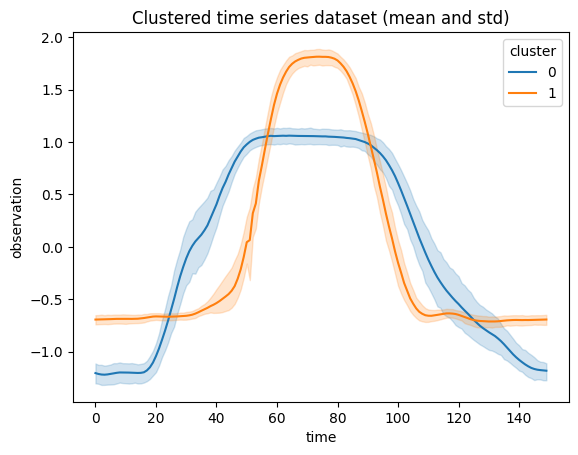

In [15]:
df_melt = df.melt(value_name="observation", var_name="time", id_vars="cluster")
sns.lineplot(df_melt, x="time", y="observation", hue="cluster")
plt.title("Clustered time series dataset (mean and std)")
plt.show()

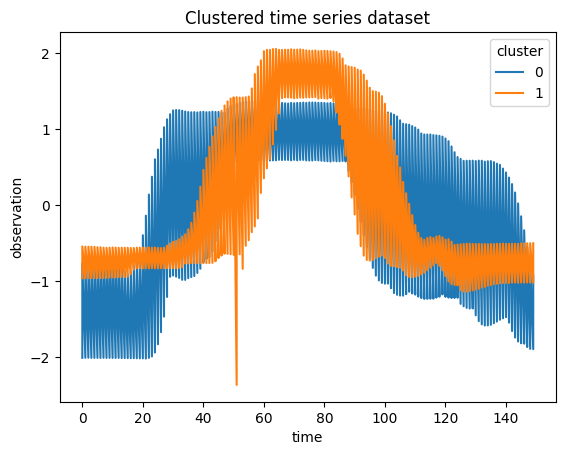

In [16]:
sns.lineplot(df_melt, x="time", y="observation", hue="cluster", estimator=None)
plt.title("Clustered time series dataset")
plt.show()

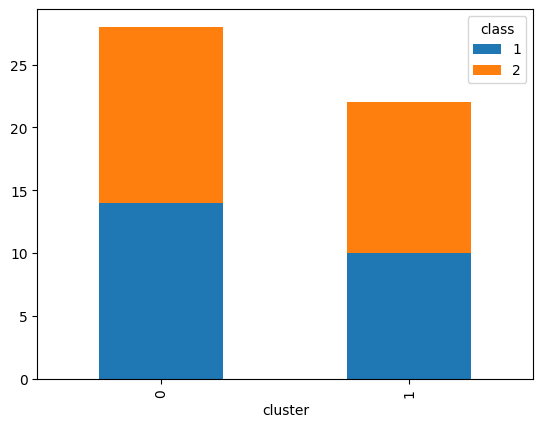

In [17]:
pd.crosstab(df["cluster"], y_train).plot(kind="bar", stacked=True)
plt.legend(title="class")

## Features-based Clustering

Custom Features Extraction

In [18]:
import scipy.stats as stats

In [19]:
def calculate_features(values):
    features = {
        'avg': np.mean(values),
        'std': np.std(values),
        'var': np.var(values),
        'med': np.median(values),
        '10p': np.percentile(values, 10),
        '25p': np.percentile(values, 25),
        '50p': np.percentile(values, 50),
        '75p': np.percentile(values, 75),
        '90p': np.percentile(values, 90),
        'iqr': np.percentile(values, 75) - np.percentile(values, 25),
        'cov': 1.0 * np.mean(values) / np.std(values),
        'skw': stats.skew(values),
        'kur': stats.kurtosis(values)
    }

    return features

In [20]:
X_train.shape

(50, 1, 150)

In [21]:
calculate_features(X_train[0][0])

{'avg': -4.0000000941139054e-10,
 'std': 0.9966610922395329,
 'var': 0.9933333327840987,
 'med': -0.6390517099999999,
 '10p': -0.662376349,
 '25p': -0.6580576549999999,
 '50p': -0.6390517099999999,
 '75p': 0.7850122350000001,
 '90p': 1.81756392,
 'iqr': 1.4430698899999999,
 'cov': -4.0134004680826487e-10,
 'skw': 1.0413347581751917,
 'kur': -0.7242667694778913}

In [22]:
feature_values = [list(calculate_features(row).values()) for row in X_train[:,0,:]]
index_values = list(range(0, X_train.shape[0]))
column_values = list(calculate_features(X_train[0][0]).keys())

CF_Train = pd.DataFrame(data = feature_values, index = index_values, columns = column_values) 
CF_Train

,avg,std,var,med,10p,25p,50p,75p,90p,iqr,cov,skw,kur
0,-4.000000e-10,0.996661,0.993333,-0.639052,-0.662376,-0.658058,-0.639052,0.785012,1.817564,1.443070,-4.013400e-10,1.041335,-0.724267
1,-7.400000e-10,0.996661,0.993333,-0.609387,-0.686238,-0.643350,-0.609387,0.719290,1.888367,1.362640,-7.424791e-10,1.091065,-0.571585
2,-1.893333e-09,0.996661,0.993333,-0.598165,-0.774612,-0.739111,-0.598165,1.096573,1.679056,1.835684,-1.899676e-09,0.885262,-1.037608
3,1.586667e-09,0.996661,0.993333,-0.559942,-0.745996,-0.741088,-0.559942,0.850966,1.766673,1.592054,1.591982e-09,0.968985,-0.842580
4,2.400000e-09,0.996661,0.993333,-0.573590,-0.643583,-0.599016,-0.573590,0.471034,2.024544,1.070050,2.408040e-09,1.261299,-0.165678
5,-1.546667e-09,0.996661,0.993333,-0.612306,-0.707283,-0.693540,-0.612306,0.745455,1.893172,1.438995,-1.551848e-09,1.051279,-0.626434
6,-6.466667e-10,0.996661,0.993333,0.729766,-1.285373,-1.267215,0.729766,0.886196,0.893341,2.153411,-6.488331e-10,-0.399082,-1.743150
7,-1.020000e-09,0.996661,0.993333,0.562284,-2.013536,-0.073071,0.562284,0.578491,0.585432,0.651562,-1.023417e-09,-1.364155,0.033430
8,3.906667e-09,0.996661,0.993333,0.042499,-1.068247,-1.047886,0.042499,1.059748,1.077842,2.107634,3.919754e-09,-0.004628,-1.904495
9,2.866667e-10,0.996661,0.993333,-0.328886,-1.172006,-0.855835,-0.328886,1.184369,1.193813,2.040205,2.876270e-10,0.115378,-1.747929


Summary Transformer Extractor

In [23]:
from sktime.transformations.series.summarize import SummaryTransformer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [24]:
transformer = SummaryTransformer()

In [25]:
F_train = transformer.fit_transform(X_train)
F_train

,mean,std,min,max,0.1,0.25,0.5,0.75,0.9
instances,,,,,,,,,
0,-4.000000e-10,1.0,-0.782461,1.845811,-0.662376,-0.658058,-0.639052,0.785012,1.817564
1,-7.400000e-10,1.0,-0.814203,1.925177,-0.686238,-0.643350,-0.609387,0.719290,1.888367
2,-1.893333e-09,1.0,-0.782672,1.703739,-0.774612,-0.739111,-0.598165,1.096573,1.679056
3,1.586667e-09,1.0,-0.792305,1.783278,-0.745996,-0.741088,-0.559942,0.850966,1.766673
4,2.400000e-09,1.0,-0.733465,2.053367,-0.643583,-0.599016,-0.573590,0.471034,2.024544
5,-1.546667e-09,1.0,-0.826486,1.926847,-0.707283,-0.693540,-0.612306,0.745455,1.893172
6,-6.466667e-10,1.0,-1.363843,0.897586,-1.285373,-1.267215,0.729766,0.886196,0.893341
7,-1.020000e-09,1.0,-2.021844,0.593964,-2.013536,-0.073071,0.562284,0.578491,0.585432
8,3.906667e-09,1.0,-1.115093,1.097158,-1.068247,-1.047886,0.042499,1.059748,1.077842


TS-Fresh Feature Extractor

In [26]:
from sktime.transformations.panel.tsfresh import TSFreshFeatureExtractor

In [27]:
ts_eff = TSFreshFeatureExtractor(default_fc_parameters="comprehensive", show_warnings=False, disable_progressbar=True) 

In [28]:
X_transform1 = ts_eff.fit_transform(X_train)
X_transform1

,var_0__variance_larger_than_standard_deviation,var_0__has_duplicate_max,var_0__has_duplicate_min,var_0__has_duplicate,var_0__sum_values,var_0__abs_energy,var_0__mean_abs_change,var_0__mean_change,var_0__mean_second_derivative_central,var_0__median,...,var_0__fourier_entropy__bins_5,var_0__fourier_entropy__bins_10,var_0__fourier_entropy__bins_100,var_0__permutation_entropy__dimension_3__tau_1,var_0__permutation_entropy__dimension_4__tau_1,var_0__permutation_entropy__dimension_5__tau_1,var_0__permutation_entropy__dimension_6__tau_1,var_0__permutation_entropy__dimension_7__tau_1,var_0__query_similarity_count__query_None__threshold_0.0,var_0__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.0,0.0,1.0,-6.000000e-08,149.000000,0.036303,0.000062,-1.988297e-05,-0.639052,...,0.191393,0.260914,0.417646,1.451715,2.244152,2.811924,3.156746,3.385291,0.0,1.841624
1,0.0,0.0,0.0,1.0,-1.110000e-07,148.999999,0.037238,0.000086,1.309291e-05,-0.609387,...,0.242673,0.242673,0.399405,1.248975,1.825556,2.310987,2.699411,3.003630,0.0,1.921007
2,0.0,0.0,0.0,1.0,-2.840000e-07,148.999999,0.035247,0.000478,1.389493e-06,-0.598165,...,0.209634,0.209634,0.417646,1.277395,1.830055,2.369587,2.811302,3.203934,0.0,1.700243
3,0.0,0.0,0.0,1.0,2.380000e-07,149.000001,0.035324,0.000170,-4.884324e-06,-0.559942,...,0.209634,0.279155,0.399405,1.320130,1.949767,2.477421,2.870676,3.107572,0.0,1.780402
4,0.0,0.0,0.0,1.0,3.600000e-07,149.000001,0.039413,-0.000216,1.003264e-05,-0.573590,...,0.242673,0.260914,0.537144,1.498303,2.329707,3.003242,3.320888,3.523892,0.0,2.043366
5,0.0,0.0,0.0,1.0,-2.320000e-07,148.999999,0.037517,-0.001095,1.841345e-05,-0.612306,...,0.191393,0.260914,0.348493,1.422296,2.181649,2.753581,3.076233,3.251420,0.0,1.920318
6,0.0,0.0,0.0,1.0,-9.700000e-08,149.000000,0.032631,-0.000126,1.147736e-04,0.729766,...,0.139933,0.139933,0.348493,1.555699,2.462123,3.195003,3.664854,3.878008,0.0,1.344322
7,0.0,0.0,0.0,1.0,-1.530000e-07,149.000000,0.030782,0.006742,-7.636390e-04,0.562284,...,0.139933,0.139933,0.417646,1.731839,2.931841,3.880347,4.376499,4.547031,0.0,2.018841
8,0.0,0.0,0.0,1.0,5.860000e-07,149.000000,0.031021,0.000238,7.517230e-06,0.042499,...,0.191393,0.209634,0.399405,1.639285,2.633392,3.407264,3.914500,4.167703,0.0,1.104414
9,0.0,0.0,0.0,1.0,4.300000e-08,149.000000,0.034238,-0.000570,2.439628e-05,-0.328886,...,0.209634,0.209634,0.348493,1.360716,1.987876,2.473431,2.802335,3.071091,0.0,1.294254


In [29]:
clusterer = DBSCAN(eps=0.5, min_samples=5)

In [30]:
clusterer.fit(F_train)

DBSCAN()

In [31]:
F_train["cluster"] = clusterer.labels_

In [32]:
pca = PCA(n_components=2)
F_train_pca = pca.fit_transform(F_train)
F_train = pd.concat(
    [F_train, pd.DataFrame(F_train_pca, columns=["pca1", "pca2"])], axis=1
)

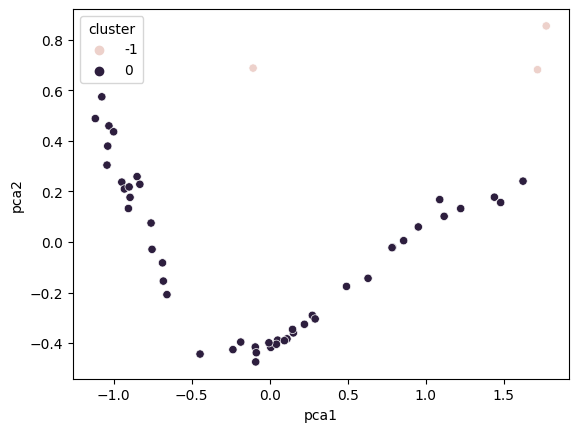

In [33]:
sns.scatterplot(F_train, x="pca1", y="pca2", hue="cluster")
plt.show()

In [34]:
df["cluster"] = clusterer.labels_

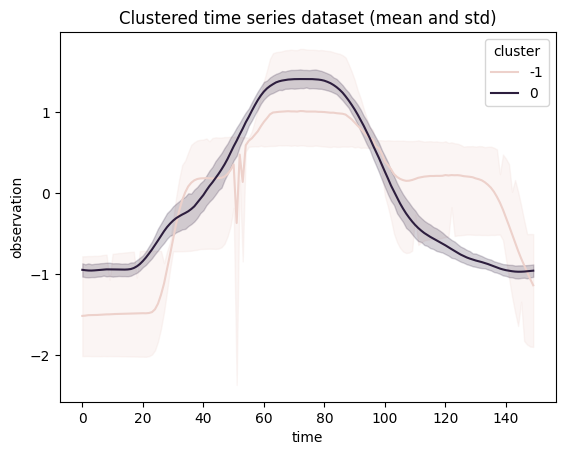

In [35]:
df_melt = df.melt(value_name="observation", var_name="time", id_vars="cluster")
sns.lineplot(df_melt, x="time", y="observation", hue="cluster")
plt.title("Clustered time series dataset (mean and std)")
plt.show()

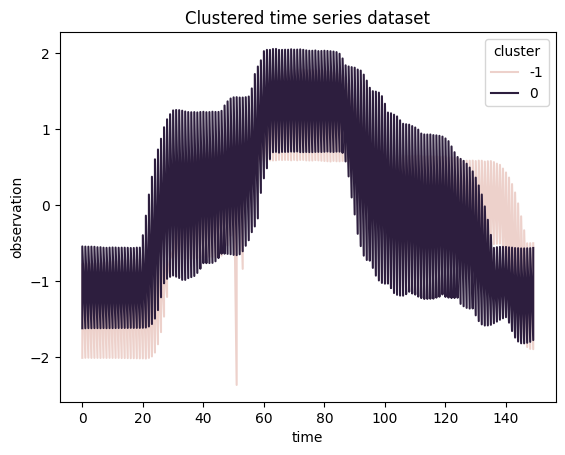

In [36]:
sns.lineplot(df_melt, x="time", y="observation", hue="cluster", estimator=None)
plt.title("Clustered time series dataset")
plt.show()

<Axes: xlabel='cluster'>

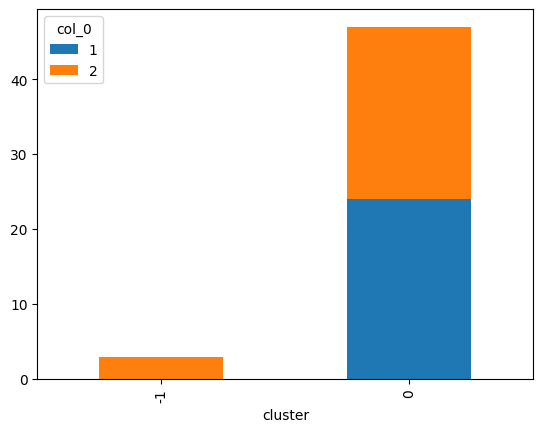

In [37]:
pd.crosstab(df["cluster"], y_train).plot(kind="bar", stacked=True)

# Approximated Clustering

In [38]:
from sktime.transformations.panel.dictionary_based import PAA

In [39]:
transformer = PAA(num_intervals=10)

In [40]:
X_paa = transformer.fit_transform(X_train)
df_paa = pd.DataFrame(np.squeeze(X_paa))

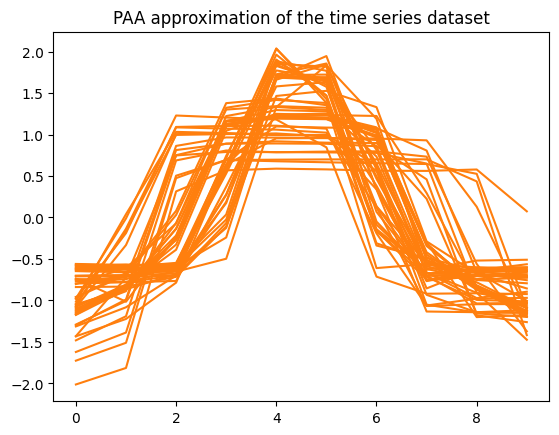

In [41]:
plt.plot(np.squeeze(X_paa.T), color="C1")
plt.title("PAA approximation of the time series dataset")
plt.show()

In [42]:
clusterer = TimeSeriesKMeans(n_clusters=4, metric="dtw")

In [43]:
%%time
clusterer.fit(X_paa)

CPU times: user 2.64 s, sys: 142 ms, total: 2.78 s
Wall time: 2.41 s


TimeSeriesKMeans(n_clusters=4)

In [44]:
df["cluster"] = clusterer.labels_
df_paa["cluster"] = clusterer.labels_

Text(0.5, 1.0, 'Clustered approximated time series dataset (mean and std)')

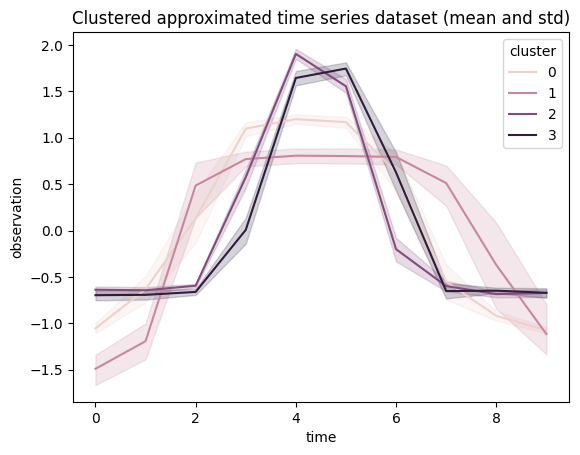

In [45]:
df_melt_paa = df_paa.melt(value_name="observation", var_name="time", id_vars="cluster")
sns.lineplot(df_melt_paa, x="time", y="observation", hue="cluster")
plt.title("Clustered approximated time series dataset (mean and std)")

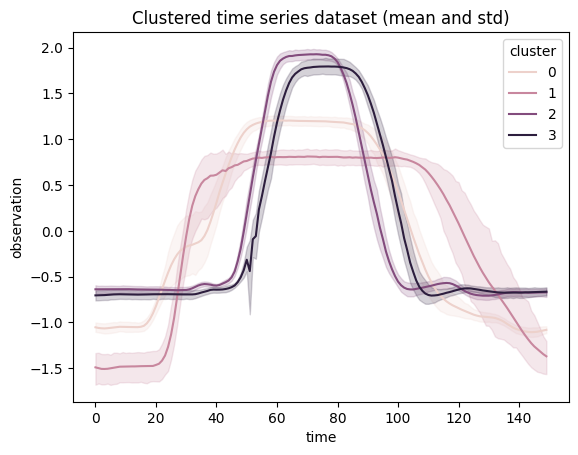

In [46]:
df_melt = df.melt(value_name="observation", var_name="time", id_vars="cluster")
sns.lineplot(df_melt, x="time", y="observation", hue="cluster")
plt.title("Clustered time series dataset (mean and std)")
plt.show()